In [ ]:
import torch
import numpy as np
import torch.nn as nn
import torch.optim as optim
import torchvision
import torchvision.transforms as transforms
from torch.utils.data import Dataset
import matplotlib.pyplot as plt
from torch.utils.data import random_split


class VectorScalarDataset(Dataset):
    def __init__(self, X, y):
        """
        X: Tensor of shape (N, p) — inputs
        y: Tensor of shape (N,)   — scalar targets
        """
        self.X = X.float()
        self.y = y.float()

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]
    

class NeuralNet(nn.Module):
    def __init__(self, hidden_size=8):
        super(NeuralNet, self).__init__()
        self.fc1 = nn.Linear(3, hidden_size)            # first hidden layer (3 -> N)
        self.fc2 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
        self.fc3 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
        self.fc4 = nn.Linear(hidden_size, hidden_size)  # first hidden layer (N -> N)
        self.fc5 = nn.Linear(hidden_size, 1)            # output layer (N -> 1 value)

    def forward(self, x):
        x = torch.relu(self.fc1(x))       # hidden layer 1 + ReLU activation, maybe try gelu
        x = torch.relu(self.fc2(x))       # hidden layer 2 + ReLU activation
        x = torch.relu(self.fc3(x))       # hidden layer 2 + ReLU activation
        x = torch.relu(self.fc4(x))       # hidden layer 2 + ReLU activation
        x = self.fc5(x).squeeze(-1)       # output layer (reduce to 1 value)
        return x
    
    def FLOPs_count(self):
        count = 2*self.fc1.in_features*self.fc1.out_features
        count += 2*self.fc2.in_features*self.fc2.out_features
        count += 2*self.fc3.in_features*self.fc3.out_features
        count += 2*self.fc4.in_features*self.fc4.out_features
        count += 2*self.fc5.in_features*self.fc5.out_features
        return count

In [28]:
# Device configuration: use GPU if available
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_data = torch.load("dataset_train.pt")
test_data = torch.load("dataset_val.pt")


y_mean = train_data["y"].mean()
y_std  = train_data["y"].std()

print(f"y mean: {y_mean:.2f}")   # expect ~1500
print(f"y std:  {y_std:.2f}")    # expect ~100-200

# Normalize
y_train_norm = (train_data["y"] - y_mean) / y_std
y_test_norm = (test_data["y"] - y_mean) / y_std

dataset = VectorScalarDataset(train_data["X"], y_train_norm)
test_dataset = VectorScalarDataset(test_data["X"], test_data["y"])

total = len(dataset)
val_size   = int(0.2 * total)
train_size = total - val_size

train_dataset, val_dataset = random_split(dataset, [train_size, val_size])
train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader  = torch.utils.data.DataLoader(val_dataset, batch_size=64, shuffle=False)

test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=4, shuffle=False)

model = NeuralNet().to(device)

print("MODEL:")
print(model)
total = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable parameters: {total}")
print(f"Total FLOPs: {model.FLOPs_count()}")

criterion = nn.HuberLoss()
optimizer = optim.Adam(model.parameters(), lr=1e-4) #, weight_decay=1e-4)
# scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
#     optimizer, mode='min', factor=0.5, patience=3, verbose=True
# )

y mean: 1516.18
y std:  151.02
MODEL:
NeuralNet(
  (fc1): Linear(in_features=3, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
)
Trainable parameters: 257
Total FLOPs: 448


In [ ]:
#Train
num_epochs = 30
avg_t_loss_s = np.zeros(num_epochs)
avg_v_loss_s = np.zeros(num_epochs)
for epoch in range(num_epochs):
    # --- Training ---
    model.train()
    total_train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)      # move inputs to GPU
        y_batch = y_batch.to(device)      # move targets to GPU

        optimizer.zero_grad()
        preds = model(X_batch)
        loss  = criterion(preds, y_batch)
        loss.backward()
        optimizer.step()

        total_train_loss += loss.item() * len(y_batch)

    # --- Validation ---
    model.eval()
    total_val_loss = 0.0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)  # move inputs to GPU
            y_batch = y_batch.to(device)  # move targets to GPU

            preds = model(X_batch)
            loss  = criterion(preds, y_batch)
            total_val_loss += loss.item() * len(y_batch)

    avg_train_loss = total_train_loss / len(train_loader.dataset)
    avg_val_loss   = total_val_loss   / len(val_loader.dataset)
    avg_t_loss_s[epoch] = avg_train_loss
    avg_v_loss_s[epoch] = avg_val_loss
    print(f"Epoch {epoch+1}: train={avg_train_loss:.4f}  val={avg_val_loss:.4f}")


Epoch 1: train=0.0017  val=0.0015
Epoch 2: train=0.0006  val=0.0004
Epoch 3: train=0.0003  val=0.0003
Epoch 4: train=0.0003  val=0.0003
Epoch 5: train=0.0003  val=0.0003
Epoch 6: train=0.0003  val=0.0003


KeyboardInterrupt: 

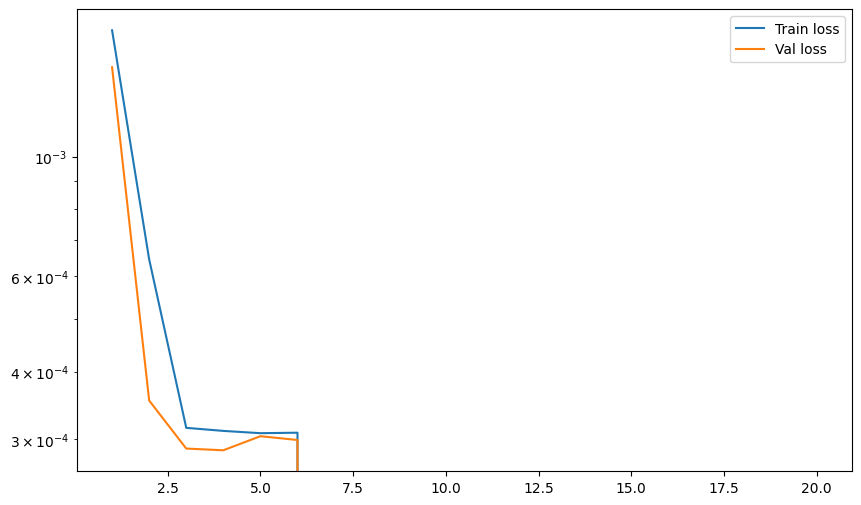

In [32]:
plt.figure(figsize=(10,6))
plt.plot(np.arange(1, num_epochs+1), avg_t_loss_s, label="Train loss")
plt.plot(np.arange(1, num_epochs+1), avg_v_loss_s, label="Val loss")
plt.yscale('log')
plt.savefig("training.png")
plt.legend()
plt.close

if True:
    torch.save({
        'model_state_dict': model.state_dict(),
        'y_mean': y_mean,
        'y_std':  y_std,
        }, 'bandpass_NN_v1.pth')

In [33]:
#Evaluation on the Test Set

model = NeuralNet()    # instantiate architecture first
model_setup_dict = torch.load('bandpass_NN_v1.pth', map_location=device)
model.load_state_dict(model_setup_dict['model_state_dict'])
y_std, y_mean = model_setup_dict['y_std'], model_setup_dict['y_mean'] 
model.to(device)
model.eval()


NeuralNet(
  (fc1): Linear(in_features=3, out_features=8, bias=True)
  (fc2): Linear(in_features=8, out_features=8, bias=True)
  (fc3): Linear(in_features=8, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=8, bias=True)
  (fc5): Linear(in_features=8, out_features=1, bias=True)
)

In [37]:
with torch.no_grad():
    # Single sample
    errs = []
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)  # move inputs to GPU
        y_batch = y_batch.to(device)  # move targets to GPU

        pred_norm = model(X_batch[0])
        pred = pred_norm * y_std + y_mean           # denormalize output
        err = abs((pred - y_batch[0].item()))/y_batch[0].item()
        print(f"Preds = {pred.item():.4f}, True = {y_batch[0].item():.4f}, err = {err}")
        errs.append(err)
        loss  = criterion(pred, y_batch)
        total_val_loss += loss.item() * len(y_batch)

Preds = 1695.2447, True = 1695.1029, err = 8.36396861378991e-05
Preds = 1428.1767, True = 1426.6996, err = 0.0010353186589078039
Preds = 1419.6509, True = 1418.1403, err = 0.0010652522196263987
Preds = 1523.6653, True = 1522.9858, err = 0.00044612207188774133
Preds = 1390.0951, True = 1388.5570, err = 0.0011076658122593991
Preds = 1585.3300, True = 1585.1897, err = 8.84775928895922e-05
Preds = 1660.7260, True = 1654.8971, err = 0.003522191532873021
Preds = 1700.5488, True = 1695.3142, err = 0.0030876989850750825
Preds = 1707.5691, True = 1702.7600, err = 0.0028242926816475214
Preds = 1732.0626, True = 1728.6213, err = 0.001990729934233509
Preds = 1348.0897, True = 1345.4294, err = 0.001977218441660518
Preds = 1548.0549, True = 1549.5347, err = 0.0009549593873777843
Preds = 1274.9742, True = 1275.7250, err = 0.0005885129374082399
Preds = 1261.5102, True = 1263.9546, err = 0.0019339527815023826
Preds = 1277.7430, True = 1278.1482, err = 0.0003169878205183474
Preds = 1361.9314, True = 135

/home/leoab/Documents/Codes/myenv/lib/python3.10/site-packages/torch/nn/modules/loss.py:1119: UserWarning: Using a target size (torch.Size([4])) that is different to the input size (torch.Size([])). This will likely lead to incorrect results due to broadcasting. Please ensure they have the same size.
  return F.huber_loss(input, target, reduction=self.reduction, delta=self.delta)


Preds = 1359.8996, True = 1357.9889, err = 0.001407023502023654
Preds = 1636.2369, True = 1636.6069, err = 0.00022612657251365486
Preds = 1508.1319, True = 1508.2847, err = 0.00010127704567575685
Preds = 1370.2115, True = 1368.3972, err = 0.0013258735162030937
Preds = 1727.0393, True = 1725.6920, err = 0.000780696731822429
Preds = 1848.1935, True = 1853.2844, err = 0.002746960251826569
Preds = 1803.4821, True = 1804.1060, err = 0.00034577721317081023
Preds = 1554.9267, True = 1554.4393, err = 0.00031350474023393745
Preds = 1468.9485, True = 1467.9720, err = 0.0006651509015896722
Preds = 1517.9189, True = 1517.2310, err = 0.0004534223495222306
Preds = 1440.7560, True = 1439.6896, err = 0.0007407629112010657
Preds = 1840.3808, True = 1844.7401, err = 0.002363128052222989
Preds = 1780.8642, True = 1778.9622, err = 0.001069213011777703
Preds = 1625.9118, True = 1625.5643, err = 0.0002137334155216364
Preds = 1743.3586, True = 1741.6476, err = 0.0009824348112889311
Preds = 1486.2927, True = 

In [38]:
max(errs)

tensor(0.0093, dtype=torch.float64)